# DINOv3 Screw Anomaly Detection — Clean Starter Notebook

This notebook builds a **self-supervised visual inspection pipeline** for screws using only **good / defect-free images**.

Core idea:

1. Split good images into `train_good` and `val_good`.
2. Build a normal patch memory bank from `train_good` only.
3. Estimate the anomaly threshold from unseen `val_good` images.
4. Inspect new images using DINOv3 patch embeddings + FAISS nearest-neighbor search.
5. Generate anomaly heatmaps.

Important fix included: **no threshold leakage**. The threshold is not computed on the same images used to build the FAISS memory bank.


In [1]:
# Colab setup
!nvidia-smi

!pip install -q     torch torchvision     transformers accelerate huggingface_hub     faiss-cpu     opencv-python pillow matplotlib tqdm scikit-learn pandas


Tue May 26 12:37:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Hugging Face login

Run this if the DINOv3 model requires access approval from Hugging Face. If you already have access, paste your token when prompted.


In [7]:
from huggingface_hub import login

# Uncomment if needed:
login()


## 2. Mount Google Drive and set paths

Put your good screw images in `GOOD_IMAGE_DIR`.

Example:

```text
/content/drive/MyDrive/good/
```


In [3]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# ===== CHANGE THESE PATHS =====
GOOD_IMAGE_DIR = "/content/drive/MyDrive/good"
TEST_IMAGE_DIR = "/content/drive/MyDrive/screw_dataset/test"
ARTIFACT_DIR = "/content/drive/MyDrive/screw_artifacts"

# Optional: set this to one image you want to inspect.
TEST_IMAGE_PATH = "/content/drive/MyDrive/Untitled Folder/004.png"


## 3. Imports and configuration

Start with `IMAGE_SIZE = 224`. Later, try `448` for better localization, but it will be slower.


In [8]:
import os
import cv2
import faiss
import json
import time
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from transformers import AutoImageProcessor, AutoModel

os.makedirs(ARTIFACT_DIR, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "facebook/dinov3-vits16-pretrain-lvd1689m"

IMAGE_SIZE = 448
PATCH_SIZE = 16
NUM_SPECIAL_TOKENS = 5  # class token + 4 register tokens for DINOv3 ViT

# Use top 5% anomalous patches for image-level scoring.
TOP_K_PERCENT = 0.05

# Keep memory bank manageable. Increase if you have enough RAM.
MAX_MEMORY_PATCHES = 70_000

print("Device:", DEVICE)
print("Model:", MODEL_NAME)
print("Image size:", IMAGE_SIZE)


Device: cuda
Model: facebook/dinov3-vits16-pretrain-lvd1689m
Image size: 448


## 4. Load DINOv3

DINOv3 is used as a **frozen feature extractor**. We are not training it.


In [9]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

print("Loaded:", MODEL_NAME)


preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loaded: facebook/dinov3-vits16-pretrain-lvd1689m


## 5. Utility functions


In [10]:
def list_image_paths(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([str(p) for p in Path(folder).rglob("*") if p.suffix.lower() in exts])


def load_image_rgb(path):
    return Image.open(path).convert("RGB")


def show_three(original, heatmap, overlay, title="Result"):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Anomaly Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(title)
    plt.axis("off")

    plt.show()


## 6. Extract DINOv3 patch embeddings

Each image is converted into patch embeddings. These patch embeddings are what we compare against the normal memory bank.


In [11]:
@torch.inference_mode()
def extract_patch_embeddings(image_path):
    """
    Extract DINOv3 patch embeddings at IMAGE_SIZE resolution.
    Works for IMAGE_SIZE = 224, 448, etc.
    """

    from torchvision.transforms import functional as TF

    image = load_image_rgb(image_path)

    # remove excess background
    image = TF.center_crop(image, IMAGE_SIZE)

    # reduce background texture/color noise
    image = image.convert("L").convert("RGB")

    # final model size
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE))

    inputs = processor(
        images=image,
        return_tensors="pt",
        do_resize=False,
        do_center_crop=False
    ).to(DEVICE)

    # Important for larger than 224 images
    outputs = model(
        **inputs,
        interpolate_pos_encoding=True
    )

    tokens = outputs.last_hidden_state[0]

    NUM_SPECIAL_TOKENS = 5  # 1 CLS token + 4 register tokens
    patch_tokens = tokens[NUM_SPECIAL_TOKENS:]

    patch_embeddings = patch_tokens.detach().cpu().numpy().astype("float32")

    patch_embeddings = patch_embeddings / (
        np.linalg.norm(patch_embeddings, axis=1, keepdims=True) + 1e-8
    )

    grid_size = IMAGE_SIZE // PATCH_SIZE
    expected_patches = grid_size * grid_size
    actual_patches = patch_embeddings.shape[0]

    if actual_patches != expected_patches:
        raise ValueError(
            f"Expected {expected_patches} patches, got {actual_patches}. "
            "The image is still being resized/cropped or positional interpolation failed."
        )

    return patch_embeddings, grid_size


## 7. Load good images and split correctly

This is the important fix.

- `train_good_paths`: used to build the FAISS memory bank.
- `val_good_paths`: used to estimate the threshold.

Do **not** compute the threshold on the same images used in the memory bank.


In [12]:
image_paths = list_image_paths(GOOD_IMAGE_DIR)

print("Number of good images:", len(image_paths))

if len(image_paths) == 0:
    raise ValueError(f"No images found in GOOD_IMAGE_DIR: {GOOD_IMAGE_DIR}")

print("First image:", image_paths[0])

# Test extraction on one image
patch_embeddings, grid_size = extract_patch_embeddings(image_paths[0])
print("Patch embeddings shape:", patch_embeddings.shape)
print("Grid size:", grid_size, "x", grid_size)

if len(image_paths) < 5:
    raise ValueError("Use at least 5 good images. More is much better, ideally 50+.")

train_good_paths, val_good_paths = train_test_split(
    image_paths,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

print("Train good images:", len(train_good_paths))
print("Validation good images:", len(val_good_paths))


Number of good images: 320
First image: /content/drive/MyDrive/good/000.png
Patch embeddings shape: (784, 384)
Grid size: 28 x 28
Train good images: 256
Validation good images: 64


## 8. Build memory bank from train-good images only


In [13]:
def build_memory_bank(paths):
    all_embeddings = []
    errors = []

    for img_path in tqdm(paths, desc="Extracting train-good patch features"):
        try:
            patch_embeddings, _ = extract_patch_embeddings(img_path)
            all_embeddings.append(patch_embeddings)
        except Exception as e:
            errors.append((img_path, str(e)))

    if len(all_embeddings) == 0:
        raise RuntimeError("No embeddings were extracted. Check your image paths and model loading.")

    memory_bank = np.concatenate(all_embeddings, axis=0).astype("float32")

    return memory_bank, errors


memory_bank, train_errors = build_memory_bank(train_good_paths)
print("Raw memory bank shape:", memory_bank.shape)
print("Train extraction errors:", len(train_errors))

if len(memory_bank) > MAX_MEMORY_PATCHES:
    idx = np.random.choice(len(memory_bank), MAX_MEMORY_PATCHES, replace=False)
    memory_bank = memory_bank[idx]

print("Final memory bank shape:", memory_bank.shape)


Extracting train-good patch features:   0%|          | 0/256 [00:00<?, ?it/s]

Raw memory bank shape: (200704, 384)
Train extraction errors: 0
Final memory bank shape: (70000, 384)


## 9. Build FAISS index


In [14]:
def build_faiss_index(memory_bank):
    embedding_dim = memory_bank.shape[1]
    index = faiss.IndexFlatIP(embedding_dim)
    index.add(memory_bank)
    return index


index = build_faiss_index(memory_bank)
embedding_dim = memory_bank.shape[1]

print("Embedding dim:", embedding_dim)
print("FAISS index size:", index.ntotal)


Embedding dim: 384
FAISS index size: 70000


In [33]:
faiss.write_index(index, "faiss_index.bin")

# --- 2. Save the Memory Bank ---
np.save("memory_bank.npy", memory_bank)

print("Saved index and memory bank successfully!")

Saved index and memory bank successfully!


## 10. Anomaly scoring and heatmap generation


In [15]:
def compute_patch_anomaly_scores(image_path, index):
    """
    Returns:
        score_map_norm: normalized 2D heatmap for visualization
        image_score: raw image-level anomaly score
        raw_score_map: raw 2D patch-level anomaly scores
    """
    patch_embeddings, grid_size = extract_patch_embeddings(image_path)

    similarities, _ = index.search(patch_embeddings, k=1)
    similarities = similarities[:, 0]

    # Since embeddings are normalized, similarity is cosine-like.
    # Higher similarity = more normal. So anomaly = 1 - similarity.
    patch_scores = 1.0 - similarities

    raw_score_map = patch_scores.reshape(grid_size, grid_size)

    # Visualization-only normalization.
    score_map_norm = (raw_score_map - raw_score_map.min()) / (raw_score_map.max() - raw_score_map.min() + 1e-8)

    # More sensitive for small defects
    k = max(1, int(0.01 * len(patch_scores)))
    image_score = float(np.mean(np.sort(patch_scores)[-k:]))

    return score_map_norm, image_score, raw_score_map


def generate_heatmap_overlay(image_path, score_map_norm, alpha=0.45):
    original_bgr = cv2.imread(image_path)

    if original_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    original = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    h, w = original.shape[:2]

    heatmap = cv2.resize(score_map_norm, (w, h))
    heatmap_uint8 = np.uint8(255 * heatmap)

    colored_heatmap = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colored_heatmap = cv2.cvtColor(colored_heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original, 1 - alpha, colored_heatmap, alpha, 0)

    return original, heatmap, overlay


def inspect_screw(image_path, index):
    start = time.time()

    score_map_norm, image_score, raw_score_map = compute_patch_anomaly_scores(
        image_path, index
    )

    original, heatmap, overlay = generate_heatmap_overlay(
        image_path, score_map_norm
    )

    latency_ms = round((time.time() - start) * 1000, 2)

    result = {
        "image_path": image_path,
        "anomaly_score": float(image_score),
        "latency_ms": latency_ms,
    }

    return result, original, heatmap, overlay, raw_score_map


## loading memory bank from drive

In [ ]:

index_path = "/content/drive/MyDrive/screw_artifacts/faiss_index.bin"
index = faiss.read_index(index_path)

In [16]:
val_scores = []

for img_path in tqdm(val_good_paths, desc="Scoring validation good images"):
    score_map_norm, image_score, raw_score_map = compute_patch_anomaly_scores(img_path, index)
    val_scores.append(image_score)

val_scores = np.array(val_scores)

print("Validation normal score min:", val_scores.min())
print("Validation normal score mean:", val_scores.mean())
print("Validation normal score std:", val_scores.std())
print("Validation normal score max:", val_scores.max())
print("95th percentile:", np.percentile(val_scores, 95))
print("99th percentile:", np.percentile(val_scores, 99))

Scoring validation good images:   0%|          | 0/64 [00:00<?, ?it/s]

Validation normal score min: 0.035344772040843964
Validation normal score mean: 0.04669301165267825
Validation normal score std: 0.006662902612750755
Validation normal score max: 0.06896267831325531
95th percentile: 0.05819208659231662
99th percentile: 0.06480502333492039


In [17]:
val_df = pd.DataFrame({
    "image_path": val_good_paths,
    "anomaly_score": val_scores
}).sort_values("anomaly_score", ascending=False)

val_df.head(10)

,image_path,anomaly_score
4,/content/drive/MyDrive/good/009.png,0.068963
47,/content/drive/MyDrive/good/194.png,0.062363
43,/content/drive/MyDrive/good/281.png,0.060640
63,/content/drive/MyDrive/good/258.png,0.058227
17,/content/drive/MyDrive/good/077.png,0.057995
8,/content/drive/MyDrive/good/244.png,0.056964
6,/content/drive/MyDrive/good/186.png,0.054843
54,/content/drive/MyDrive/good/017.png,0.054076
30,/content/drive/MyDrive/good/075.png,0.053918
21,/content/drive/MyDrive/good/211.png,0.053839


GOOD validation image: /content/drive/MyDrive/good/009.png
Score: 0.06896267831325531


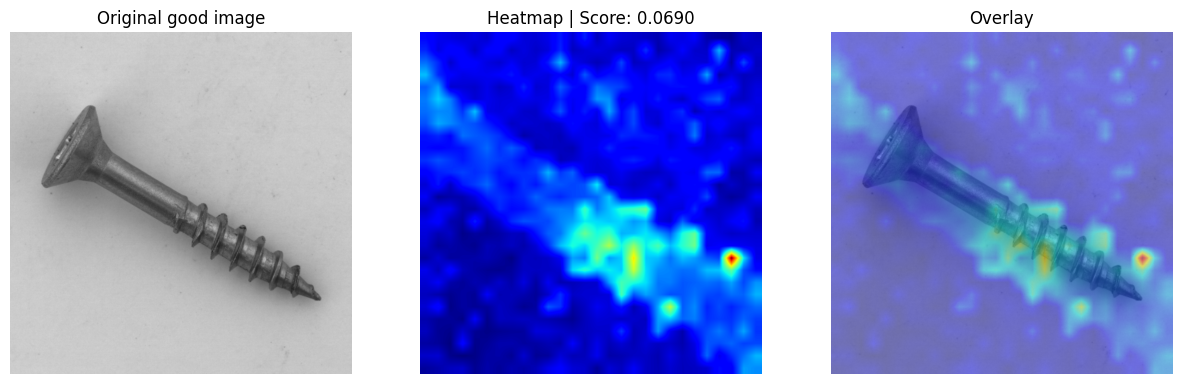

GOOD validation image: /content/drive/MyDrive/good/194.png
Score: 0.06236322596669197


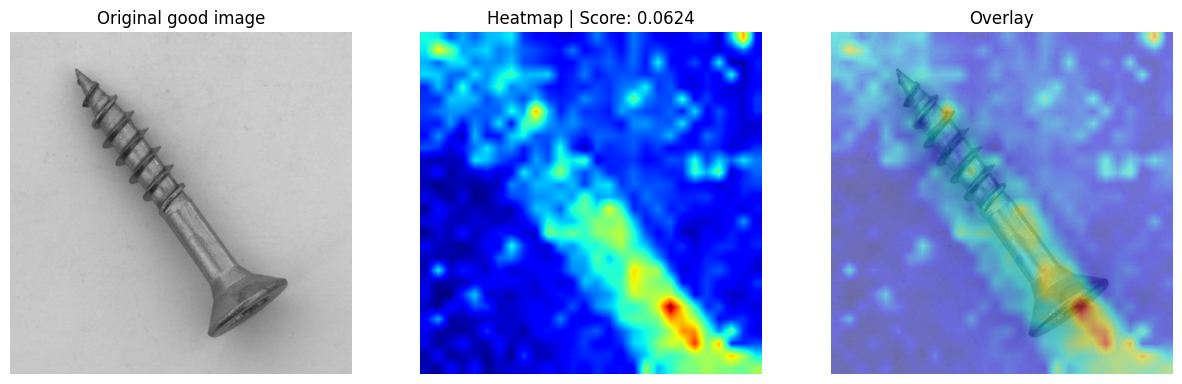

GOOD validation image: /content/drive/MyDrive/good/281.png
Score: 0.060639601200819016


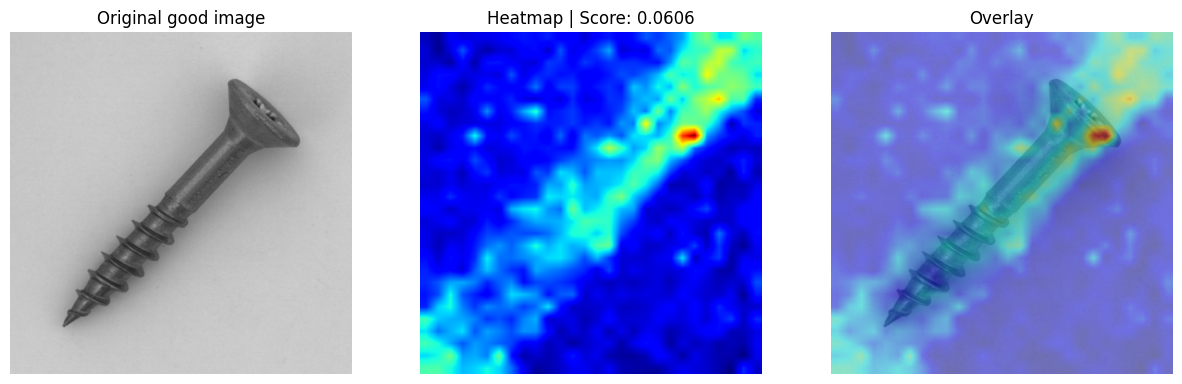

GOOD validation image: /content/drive/MyDrive/good/258.png
Score: 0.05822683125734329


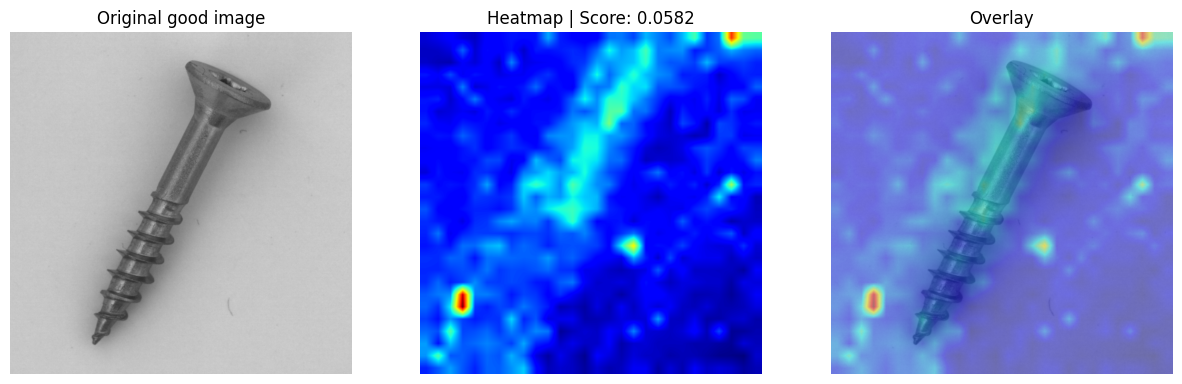

GOOD validation image: /content/drive/MyDrive/good/077.png
Score: 0.05799520015716553


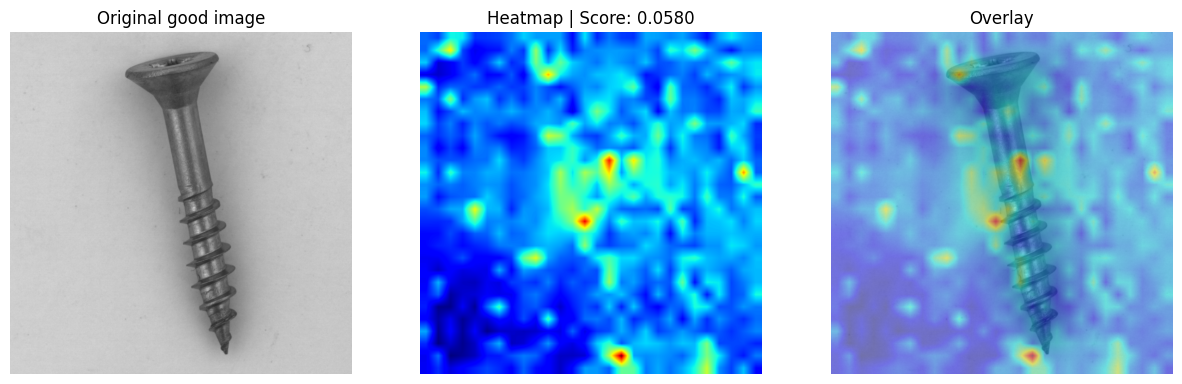

GOOD validation image: /content/drive/MyDrive/good/244.png
Score: 0.056963689625263214


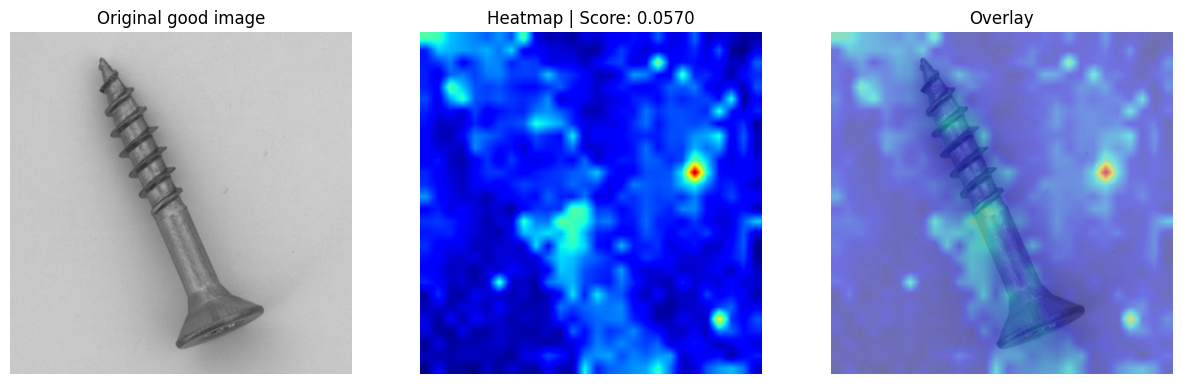

GOOD validation image: /content/drive/MyDrive/good/186.png
Score: 0.0548434779047966


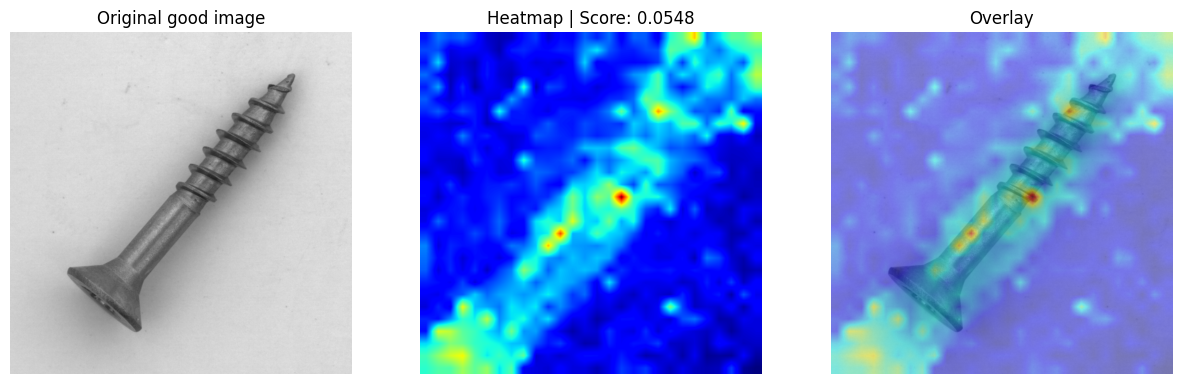

GOOD validation image: /content/drive/MyDrive/good/017.png
Score: 0.0540756918489933


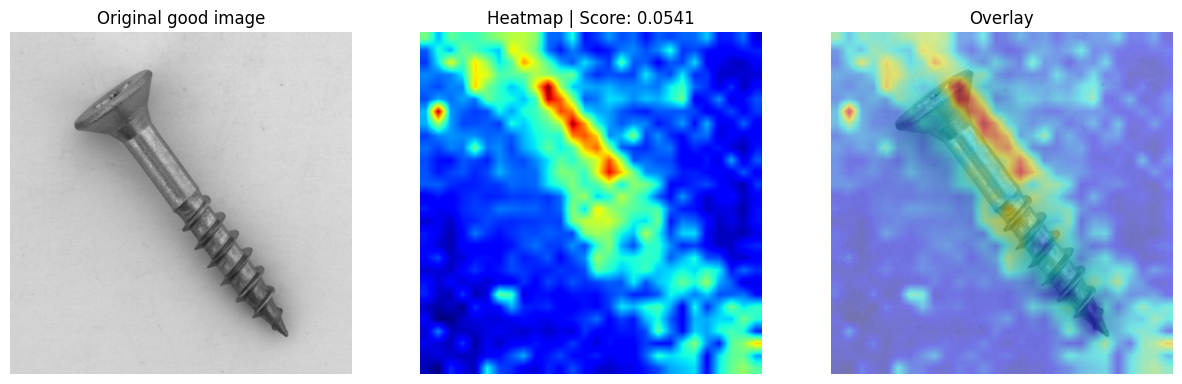

GOOD validation image: /content/drive/MyDrive/good/075.png
Score: 0.05391828343272209


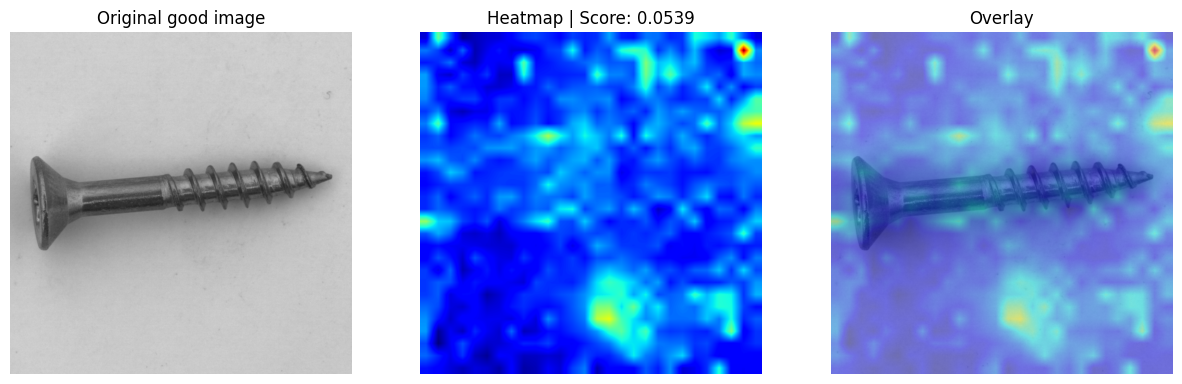

GOOD validation image: /content/drive/MyDrive/good/211.png
Score: 0.053838711231946945


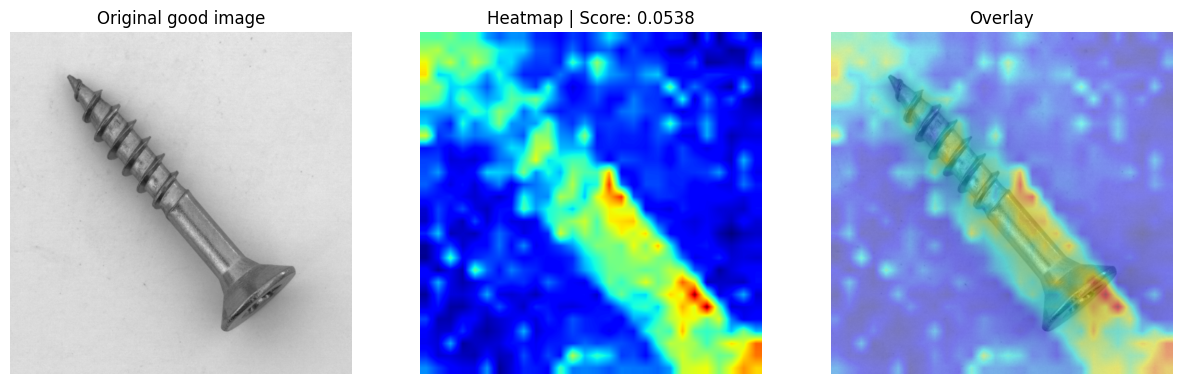

In [18]:
for _, row in val_df.head(10).iterrows():
    img_path = row["image_path"]

    result, original, heatmap, overlay, raw_score_map = inspect_screw(img_path, index)

    print("GOOD validation image:", img_path)
    print("Score:", result["anomaly_score"])

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original good image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title(f"Heatmap | Score: {result['anomaly_score']:.4f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

TEST_IMAGE_DIR = "/content/drive/MyDrive/screw_dataset/test"  # change if your test folder path is different

test_paths = sorted([
    str(p) for p in Path(TEST_IMAGE_DIR).rglob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
])

print("Number of test images:", len(test_paths))
print(test_paths[:5])

Number of test images: 160
['/content/drive/MyDrive/screw_dataset/test/good/000.png', '/content/drive/MyDrive/screw_dataset/test/good/001.png', '/content/drive/MyDrive/screw_dataset/test/good/002.png', '/content/drive/MyDrive/screw_dataset/test/good/003.png', '/content/drive/MyDrive/screw_dataset/test/good/004.png']


In [20]:
test_results = []

for img_path in tqdm(test_paths, desc="Scoring test images"):
    try:
        result, original, heatmap, overlay, raw_score_map = inspect_screw(img_path, index)

        test_results.append({
            "image_path": img_path,
            "anomaly_score": result["anomaly_score"],
            "latency_ms": result["latency_ms"]
        })

    except Exception as e:
        print("Error:", img_path, e)

test_df = pd.DataFrame(test_results)
test_df = test_df.sort_values("anomaly_score", ascending=False)

test_df.head(20)

Scoring test images:   0%|          | 0/160 [00:00<?, ?it/s]

,image_path,anomaly_score,latency_ms
104,/content/drive/MyDrive/screw_dataset/test/scra...,0.361910,1625.48
92,/content/drive/MyDrive/screw_dataset/test/scra...,0.320542,1901.21
95,/content/drive/MyDrive/screw_dataset/test/scra...,0.287151,1171.17
105,/content/drive/MyDrive/screw_dataset/test/scra...,0.249754,1378.28
108,/content/drive/MyDrive/screw_dataset/test/scra...,0.248489,1293.45
96,/content/drive/MyDrive/screw_dataset/test/scra...,0.244759,1409.04
98,/content/drive/MyDrive/screw_dataset/test/scra...,0.243060,1085.10
103,/content/drive/MyDrive/screw_dataset/test/scra...,0.237191,1653.53
142,/content/drive/MyDrive/screw_dataset/test/thre...,0.227501,1581.99
110,/content/drive/MyDrive/screw_dataset/test/scra...,0.214789,1164.81


TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/015.png
Anomaly score: 0.36190977692604065
Latency: 666.48 ms


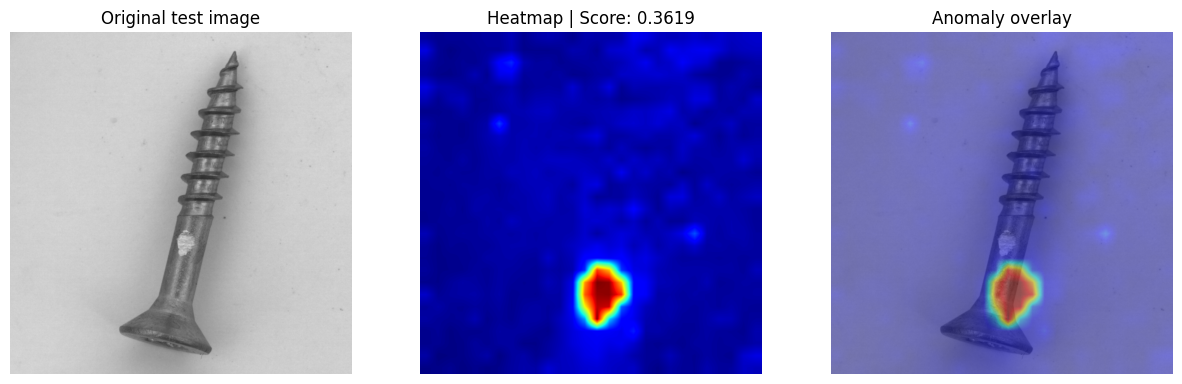

TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/003.png
Anomaly score: 0.3205421268939972
Latency: 561.33 ms


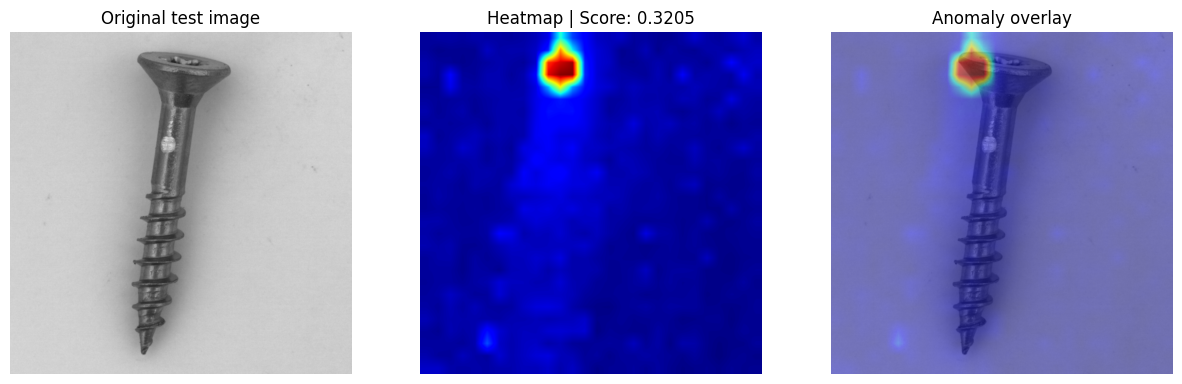

TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/006.png
Anomaly score: 0.2871505916118622
Latency: 592.81 ms


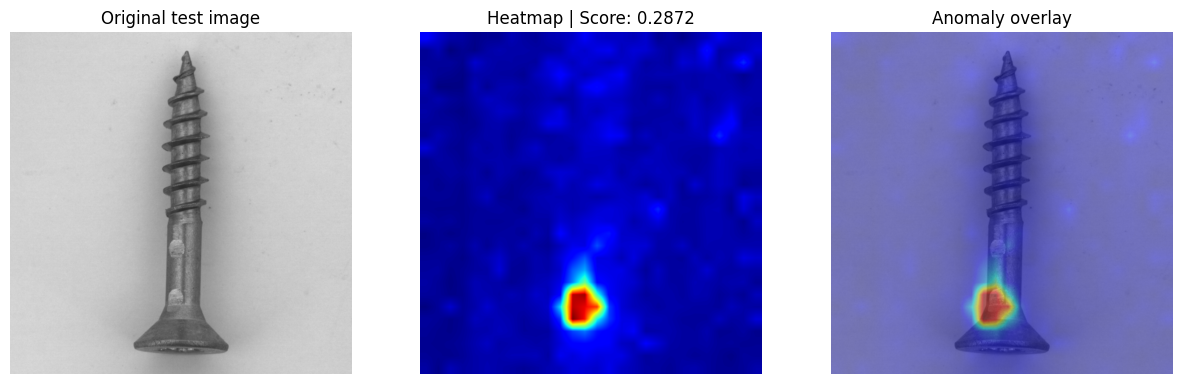

TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/016.png
Anomaly score: 0.24975371360778809
Latency: 1086.47 ms


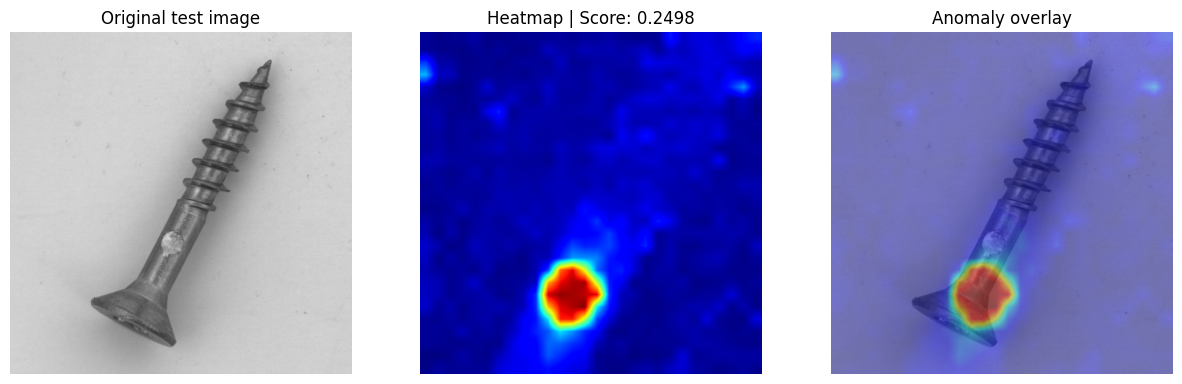

TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/019.png
Anomaly score: 0.24848875403404236
Latency: 1037.14 ms


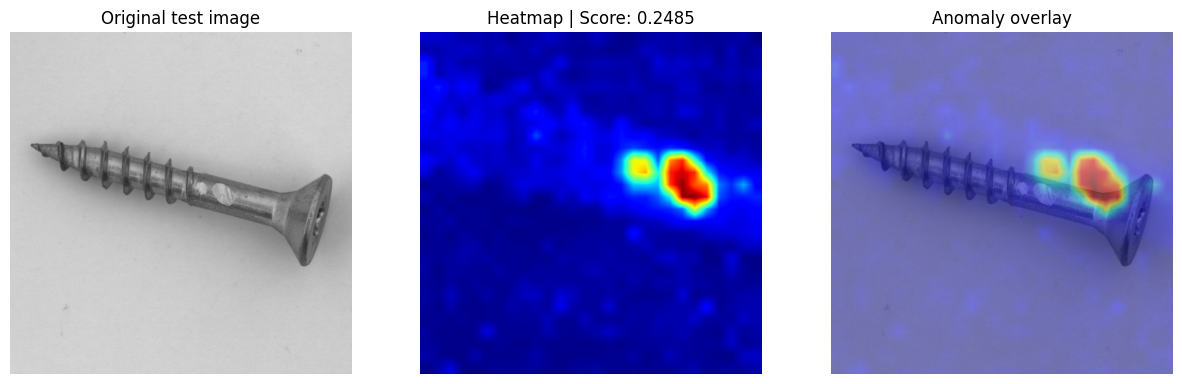

TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/007.png
Anomaly score: 0.24475857615470886
Latency: 936.1 ms


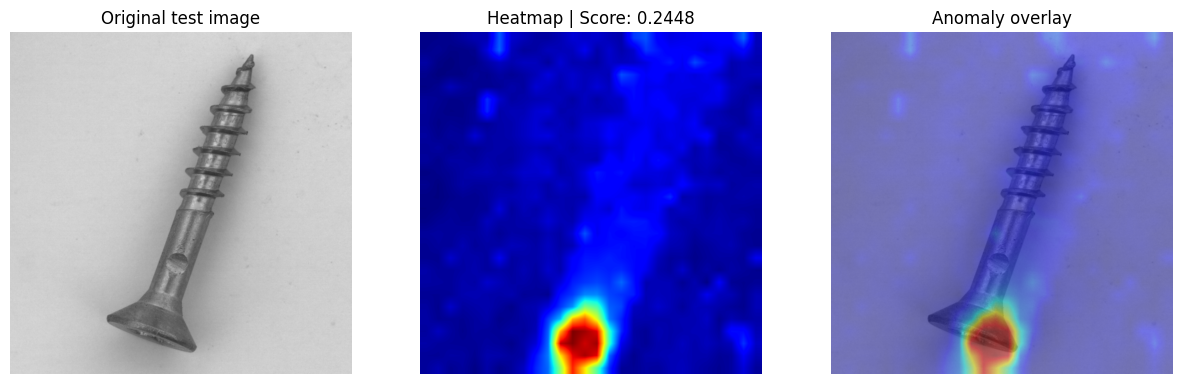

TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/009.png
Anomaly score: 0.24306035041809082
Latency: 576.29 ms


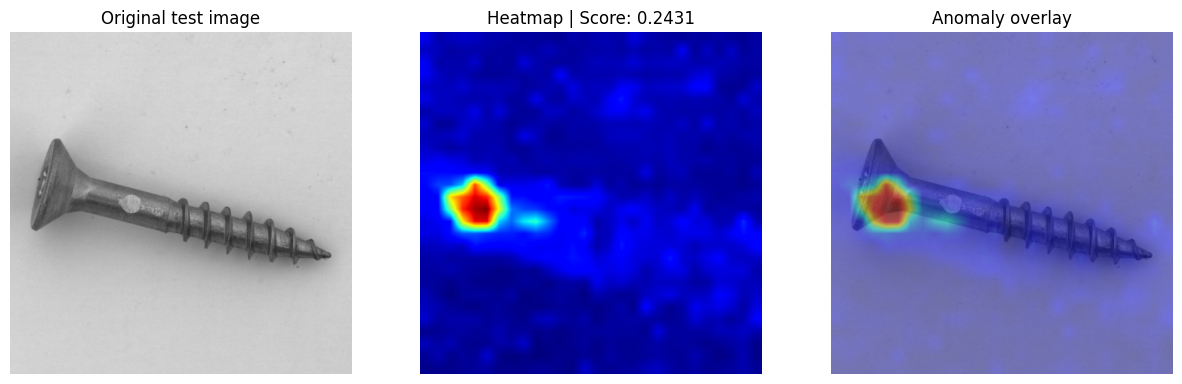

TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/014.png
Anomaly score: 0.23719099164009094
Latency: 581.15 ms


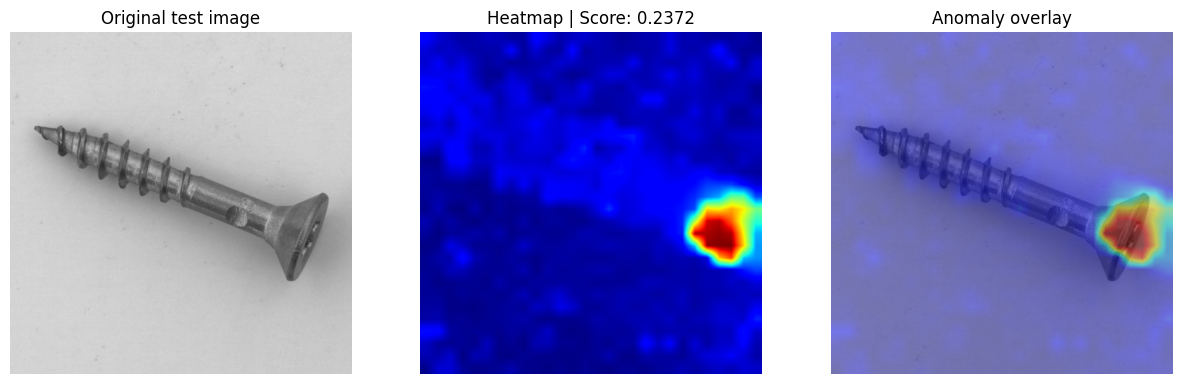

TEST image: /content/drive/MyDrive/screw_dataset/test/thread_top/005.png
Anomaly score: 0.22750096023082733
Latency: 565.52 ms


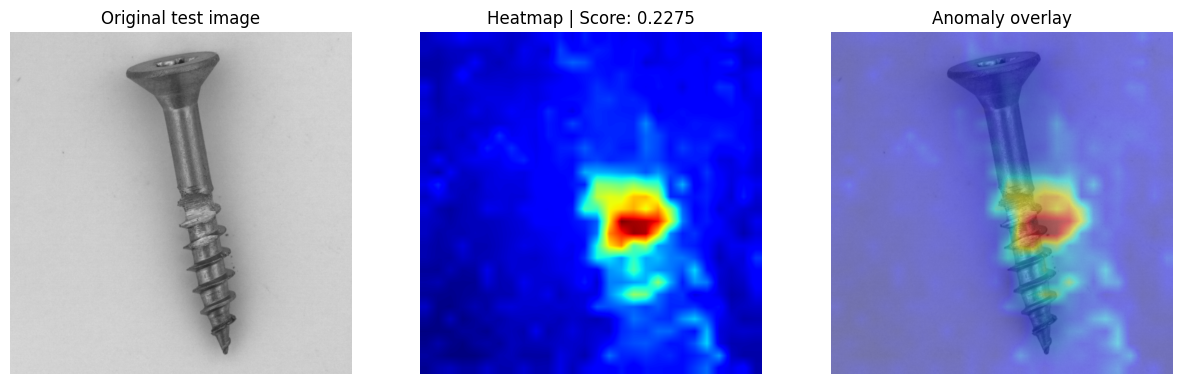

TEST image: /content/drive/MyDrive/screw_dataset/test/scratch_neck/021.png
Anomaly score: 0.21478910744190216
Latency: 581.16 ms


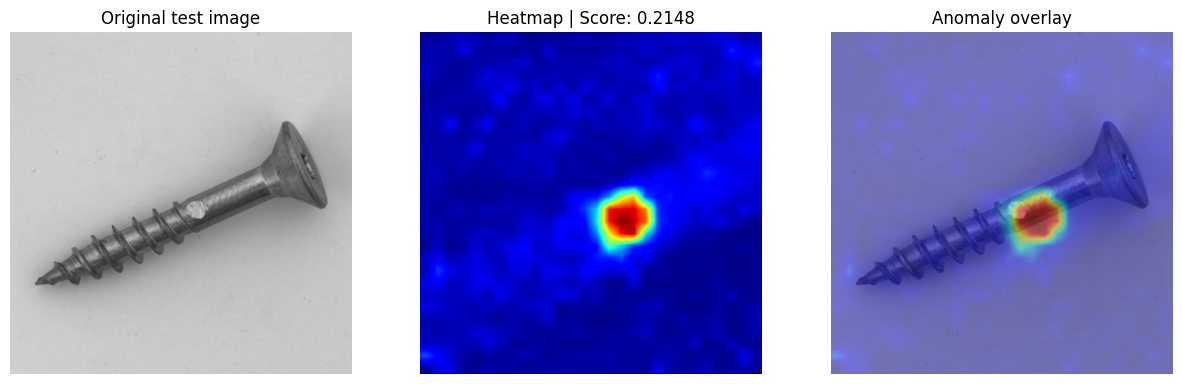

In [21]:
TOP_N = 10

for _, row in test_df.head(TOP_N).iterrows():
    img_path = row["image_path"]

    result, original, heatmap, overlay, raw_score_map = inspect_screw(img_path, index)

    print("TEST image:", img_path)
    print("Anomaly score:", result["anomaly_score"])
    print("Latency:", result["latency_ms"], "ms")

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original test image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title(f"Heatmap | Score: {result['anomaly_score']:.4f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Anomaly overlay")
    plt.axis("off")

    plt.show()

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.auto import tqdm



image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

test_paths = sorted([
    str(p) for p in Path(TEST_IMAGE_DIR).rglob("*")
    if p.suffix.lower() in image_exts
])

print("Total test images:", len(test_paths))
print(test_paths[:5])

Total test images: 160
['/content/drive/MyDrive/screw_dataset/test/good/000.png', '/content/drive/MyDrive/screw_dataset/test/good/001.png', '/content/drive/MyDrive/screw_dataset/test/good/002.png', '/content/drive/MyDrive/screw_dataset/test/good/003.png', '/content/drive/MyDrive/screw_dataset/test/good/004.png']


In [30]:
THRESHOLD = np.percentile(val_scores, 92)

print("Threshold:", THRESHOLD)

Threshold: 0.05687888115644455


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def infer_defect_type_from_path(path):
    return Path(path).parent.name.lower()

def binary_label_from_defect_type(defect_type):
    return 0 if defect_type == "good" else 1

test_df["defect_type"] = test_df["image_path"].apply(infer_defect_type_from_path)
test_df["y_true"] = test_df["defect_type"].apply(binary_label_from_defect_type)

test_df["y_pred"] = (test_df["anomaly_score"] > THRESHOLD).astype(int)

print("Accuracy:", accuracy_score(test_df["y_true"], test_df["y_pred"]))
print("Precision:", precision_score(test_df["y_true"], test_df["y_pred"]))
print("Recall:", recall_score(test_df["y_true"], test_df["y_pred"]))
print("F1:", f1_score(test_df["y_true"], test_df["y_pred"]))

print("\nConfusion Matrix:")
print(confusion_matrix(test_df["y_true"], test_df["y_pred"]))

print("\nClassification Report:")
print(classification_report(test_df["y_true"], test_df["y_pred"], target_names=["good", "defective"]))

test_df.head()

Accuracy: 0.76875
Precision: 0.91
Recall: 0.7647058823529411
F1: 0.8310502283105022

Confusion Matrix:
[[32  9]
 [28 91]]

Classification Report:
              precision    recall  f1-score   support

        good       0.53      0.78      0.63        41
   defective       0.91      0.76      0.83       119

    accuracy                           0.77       160
   macro avg       0.72      0.77      0.73       160
weighted avg       0.81      0.77      0.78       160



,image_path,anomaly_score,latency_ms,defect_type,y_true,y_pred
104,/content/drive/MyDrive/screw_dataset/test/scra...,0.361910,1625.48,scratch_neck,1,1
92,/content/drive/MyDrive/screw_dataset/test/scra...,0.320542,1901.21,scratch_neck,1,1
95,/content/drive/MyDrive/screw_dataset/test/scra...,0.287151,1171.17,scratch_neck,1,1
105,/content/drive/MyDrive/screw_dataset/test/scra...,0.249754,1378.28,scratch_neck,1,1
108,/content/drive/MyDrive/screw_dataset/test/scra...,0.248489,1293.45,scratch_neck,1,1


### Single Image Inference
Use this cell to test a single image and get a definitive Pass/Fail result based on the optimal threshold.

Image: /content/drive/MyDrive/screw_dataset/test/thread_side/012.png
Anomaly score: 0.08400833606719971
Threshold: 0.05687888115644455
Prediction: DEFECTIVE
Latency: 966.04 ms


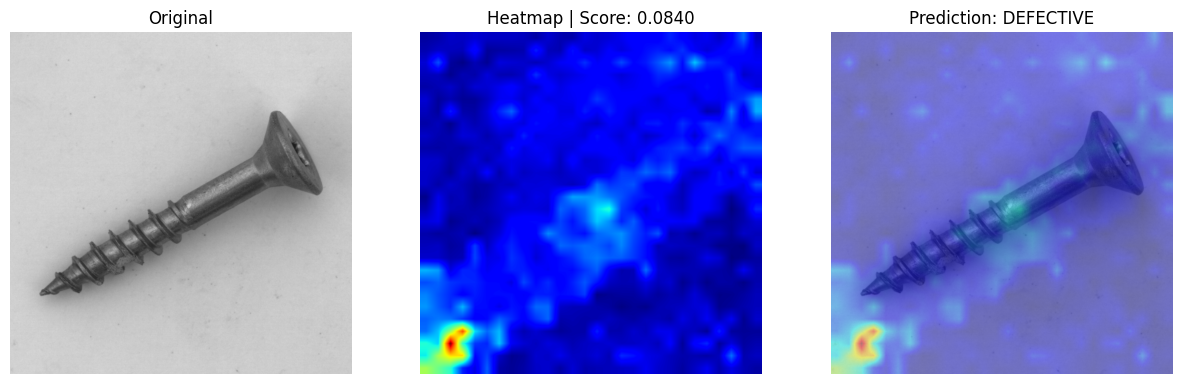

In [32]:
SINGLE_IMAGE_PATH = "/content/drive/MyDrive/screw_dataset/test/thread_side/012.png"

result, original, heatmap, overlay, raw_score_map = inspect_screw(
    SINGLE_IMAGE_PATH,
    index
)

score = result["anomaly_score"]
prediction = "DEFECTIVE" if score > THRESHOLD else "GOOD"

print("Image:", SINGLE_IMAGE_PATH)
print("Anomaly score:", score)
print("Threshold:", THRESHOLD)
print("Prediction:", prediction)
print("Latency:", result["latency_ms"], "ms")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title(f"Heatmap | Score: {score:.4f}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Prediction: {prediction}")
plt.axis("off")

plt.show()